In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

#github directory
url = "https://raw.githubusercontent.com/AniruddhaJ-2002/ML-Material-Science/refs/heads/main/data/fea_data.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (32, 7)

First 5 rows:
  geometry     load_type  force_vertical  force_lateral  force_longitudinal  \
0       V1      vertical            1500              0                   0   
1       V1       lateral               0            750                   0   
2       V1  longitudinal               0              0                1000   
3       V1      combined            1500            750                1000   
4       V1      vertical             750              0                   0   

   von_mises_mpa  displacement_mm  
0          66.13           0.0540  
1          33.12           0.0230  
2          72.90           0.2500  
3         153.90           0.3200  
4          33.06           0.0272  

Basic statistics:
       force_vertical  force_lateral  force_longitudinal  von_mises_mpa  \
count       32.000000      32.000000           32.000000      32.000000   
mean       703.125000     351.500000          468.750000      68.547500   
std        817.987055     4

**Exploratory Data Analysis** <br>
Always done before any ML. Understand the dat before modelling it. <br>
The key questions are, Is there signal?Are features informative? Is data clean? <br>
Tools: Scatter plots, distributions, corelation matrics. <br>
A model trained without EDA is a model trained blind. EDA also tells you which model to use - linear relationship: Linear regression. Complex non-linear: neural network.

In [2]:
# Encode geometry as binary: V1=0 ; V2=1
df['geometry_encoded'] = (df['geometry']=='V2').astype(int)

# Encode load type as numbers
load_map = {'vertical':0,
            'lateral':1,
            'longitudinal':2,
            'combined':3}
df['load_encoded'] = df['load_type'].map(load_map)

print("Encoded dataset:")
print(df.head(8))

Encoded dataset:
  geometry     load_type  force_vertical  force_lateral  force_longitudinal  \
0       V1      vertical            1500              0                   0   
1       V1       lateral               0            750                   0   
2       V1  longitudinal               0              0                1000   
3       V1      combined            1500            750                1000   
4       V1      vertical             750              0                   0   
5       V1       lateral               0            375                   0   
6       V1  longitudinal               0              0                 500   
7       V1      combined             750            375                 500   

   von_mises_mpa  displacement_mm  geometry_encoded  load_encoded  
0          66.13           0.0540                 0             0  
1          33.12           0.0230                 0             1  
2          72.90           0.2500                 0             2  

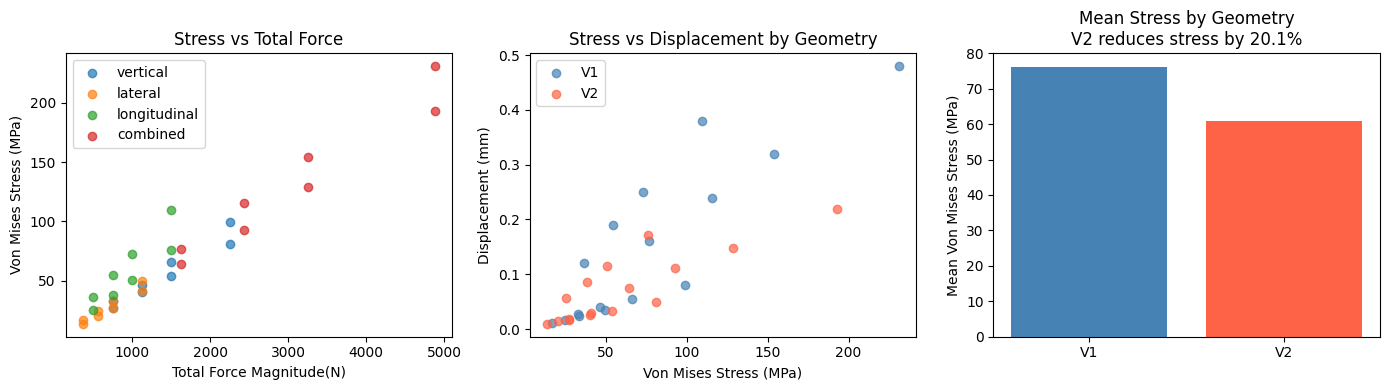

In [3]:
# Plot 1: Von Mises stress distribution
fig, axes = plt.subplots(1,3,figsize=(14,4))

# Stress by load type
for load in df['load_type'].unique():
  mask = df['load_type'] == load
  axes[0].scatter(df[mask]['force_vertical'] +
                  df[mask]['force_lateral'] +
                  df[mask]['force_longitudinal'],
                  df[mask]['von_mises_mpa'],
                  label=load, alpha=0.7)
axes[0].set_xlabel("Total Force Magnitude(N)")
axes[0].set_ylabel("Von Mises Stress (MPa)")
axes[0].set_title("Stress vs Total Force")
axes[0].legend()

# Stress by geometry
colors = {'V1': 'steelblue', 'V2': 'tomato'}
for geom in ['V1', 'V2']:
  mask = df['geometry'] == geom
  axes[1].scatter(df[mask]['von_mises_mpa'],
                  df[mask]['displacement_mm'],
                  c=colors[geom], label=geom, alpha=0.7)
axes[1].set_xlabel("Von Mises Stress (MPa)")
axes[1].set_ylabel("Displacement (mm)")
axes[1].set_title("Stress vs Displacement by Geometry")
axes[1].legend()

# Stress reduction V1 and V2
v1_stress = df[df['geometry']=='V1']['von_mises_mpa'].values
v2_stress = df[df['geometry']=='V2']['von_mises_mpa'].values
axes[2].bar(['V1', 'V2'],
            [v1_stress.mean(), v2_stress.mean()],
            color=['steelblue','tomato'])
axes[2].set_ylabel("Mean Von Mises Stress (MPa)")
axes[2].set_title(f"Mean Stress by Geometry\nV2 reduces stress by {(1-v2_stress.mean()/v1_stress.mean())*100:.1f}%")

plt.tight_layout()
plt.savefig('eda_plots.png',dpi=150)
plt.show()


**Summery** <br>
1. Strong linear relationship between force magniture and Von Mises Stress. Linear surrogate model is appropriate as baseline
2. V2 geometry reduces mean stress by 20.1% compared to V1. Geometry is an informative feature
3. Strong correlation between stress and displacment. Both outputs follow same physical trend, models trained on one will likely generalize to the other. <br>

**Conclusion** <br>
Dataset has clear learnable signal. linear regression is justified as baseline. Neural network will be the upgrade in Phase 2.

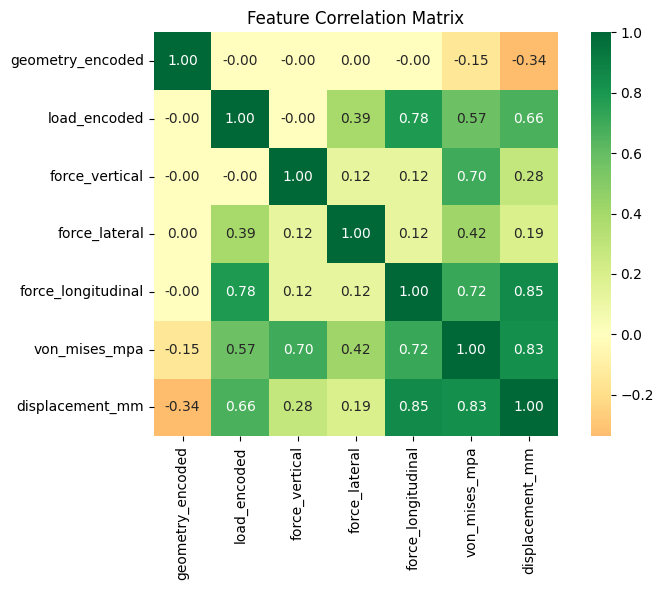

In [7]:
# Correlation matrix
corr_features = df[['geometry_encoded', 'load_encoded',
                    'force_vertical', 'force_lateral',
                    'force_longitudinal',
                    'von_mises_mpa','displacement_mm']]

corr = corr_features.corr()

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig('correaltion_matrix.png', dpi=150)
plt.show()

**Feature importance analysis** <br>
Displacement(0.83) has highest correlation with von_mises_mpa. Stress and displacement are physically coupled. Stiffer regions resist both simultaneously. <br>
Braking force(0.72): Braking load dominates stress in this bracket. Consistant with the FEM results, where braking produced highest stress. <br>
Vertical Force(0.70): Engine weight is the second most significant load. <br>
Cornering force contributes least to stress. Bracket geometry resists lateralloads more effectively. <br>
Geometry(-0.15): small negative correlation. V2(encoded as 1) slightly reduces stress- consistant with 20.1% reduction observed. <br>
Load type(0.57): Combined load naturally produces higher stress

**Feature Matrix Definition**

In [8]:
# features and targets
feature_cols = ['geometry_encoded','load_encoded',
                'force_vertical','force_lateral',
                'force_longitudinal']

X = df[feature_cols].values
y_stress = df['von_mises_mpa'].values
y_disp = df['displacement_mm'].values

print(f"Feature matrix X: {X.shape}")
print(f"Stress target: {y_stress.shape}")
print(f"Displacement target: {y_disp.shape}")
print(f"\nFeature names: {feature_cols}")

Feature matrix X: (32, 5)
Stress target: (32,)
Displacement target: (32,)

Feature names: ['geometry_encoded', 'load_encoded', 'force_vertical', 'force_lateral', 'force_longitudinal']


**Test-Train Split** (22-10)

In [9]:
# Train Test Split
X_train, X_test, y_stress_train, y_stress_test, y_disp_train, y_disp_test = train_test_split(
    X, y_stress, y_disp,
    test_size = 0.3,
    random_state = 42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 22
Testing samples:  10


In [10]:
#Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature means after scaling: {X_train_scaled.mean(axis=0).round(6)}")
print(f"Feature stds after scaling:  {X_train_scaled.std(axis=0).round(6)}")


Feature means after scaling: [ 0.  0. -0.  0.  0.]
Feature stds after scaling:  [1. 1. 1. 1. 1.]


**Baseline Surrogate Model: Linear Regression**

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Train linear surrogate for stress
lr_stress = LinearRegression()
lr_stress.fit(X_train_scaled, y_stress_train)

# Train linear surrogate for displacment
lr_disp = LinearRegression()
lr_disp.fit(X_train_scaled, y_disp_train)

# Predictions
y_stress_pred = lr_stress.predict(X_test_scaled)
y_disp_pred = lr_disp.predict(X_test_scaled)

# Metrics
r2_stress = r2_score(y_stress_test, y_stress_pred)
r2_disp = r2_score(y_disp_test, y_disp_pred)
mse_stress = mean_squared_error(y_stress_test, y_stress_pred)
mse_disp = mean_squared_error(y_disp_test, y_disp_pred)

print("=== LINEAR SURROGATE MODEL RESULTS ===")
print(f"\nVon Mises Stress:")
print(f"  R²:   {r2_stress:.4f}")
print(f"  MSE:  {mse_stress:.4f}")
print(f"  RMSE: {np.sqrt(mse_stress):.4f} MPa")

print(f"\nDisplacement:")
print(f"  R²:   {r2_disp:.4f}")
print(f"  MSE:  {mse_disp:.6f}")
print(f"  RMSE: {np.sqrt(mse_disp):.6f} mm")

# Cross validation on full dataset
cv_stress = cross_val_score(LinearRegression(),
                             scaler.transform(X), y_stress,
                             cv=5, scoring='r2')
cv_disp = cross_val_score(LinearRegression(),
                           scaler.transform(X), y_disp,
                           cv=5, scoring='r2')

print(f"\n=== 5-FOLD CROSS VALIDATION ===")
print(f"Stress R²:      {cv_stress.mean():.4f} ± {cv_stress.std():.4f}")
print(f"Displacement R²: {cv_disp.mean():.4f} ± {cv_disp.std():.4f}")

=== LINEAR SURROGATE MODEL RESULTS ===

Von Mises Stress:
  R²:   0.9213
  MSE:  69.2748
  RMSE: 8.3231 MPa

Displacement:
  R²:   -0.4303
  MSE:  0.005605
  RMSE: 0.074864 mm

=== 5-FOLD CROSS VALIDATION ===
Stress R²:      0.9649 ± 0.0195
Displacement R²: -0.2129 ± 1.4524


**Check whats happening with displacement**

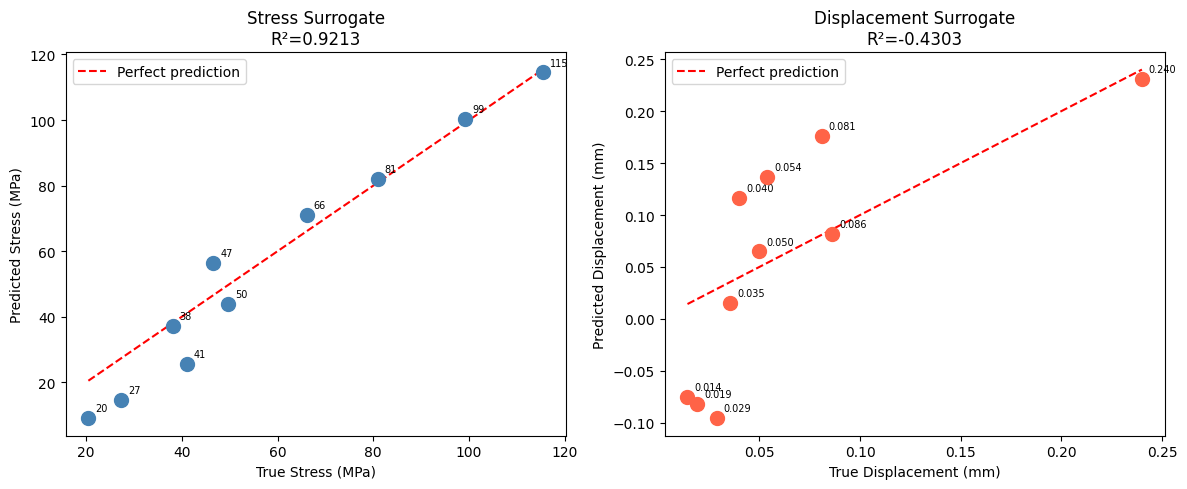

In [12]:
# Plot predicted vs actual for both
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stress
axes[0].scatter(y_stress_test, y_stress_pred,
                color='steelblue', s=100, zorder=5)
axes[0].plot([y_stress_test.min(), y_stress_test.max()],
             [y_stress_test.min(), y_stress_test.max()],
             'r--', label='Perfect prediction')
for i, (true, pred) in enumerate(zip(y_stress_test, y_stress_pred)):
    axes[0].annotate(f'{true:.0f}', (true, pred),
                     textcoords="offset points",
                     xytext=(5,5), fontsize=7)
axes[0].set_xlabel("True Stress (MPa)")
axes[0].set_ylabel("Predicted Stress (MPa)")
axes[0].set_title(f"Stress Surrogate\nR²={r2_stress:.4f}")
axes[0].legend()

# Displacement
axes[1].scatter(y_disp_test, y_disp_pred,
                color='tomato', s=100, zorder=5)
axes[1].plot([y_disp_test.min(), y_disp_test.max()],
             [y_disp_test.min(), y_disp_test.max()],
             'r--', label='Perfect prediction')
for i, (true, pred) in enumerate(zip(y_disp_test, y_disp_pred)):
    axes[1].annotate(f'{true:.3f}', (true, pred),
                     textcoords="offset points",
                     xytext=(5,5), fontsize=7)
axes[1].set_xlabel("True Displacement (mm)")
axes[1].set_ylabel("Predicted Displacement (mm)")
axes[1].set_title(f"Displacement Surrogate\nR²={r2_disp:.4f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('linear_surrogate_results.png', dpi=150)
plt.show()

The model is predicting negative displacement values, which is physically impossible. This may be because of only 22 data points in training. the linear model learned a slppe that works for large displacments but extrapolates incorrectly into negative territory for small ones

**Predict displacement from stress, rather than from raw features, since we have 0.83 correlation between them**

Displacement from Stress R²:   0.1218
Displacement from Stress RMSE: 0.058663 mm


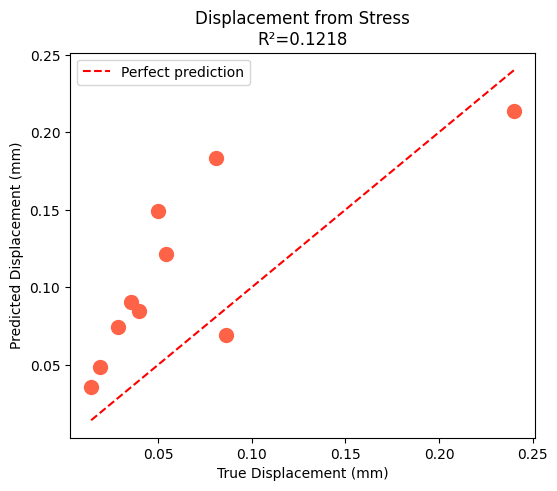

In [13]:
# Predict displacement from stress instead of raw features
# Physical reasoning: Both are responses for same loading
# Predict displacement from stress instead of raw features
# Physical reasoning: both are responses to the same loading
lr_disp_v2 = LinearRegression()
lr_disp_v2.fit(y_stress_train.reshape(-1,1), y_disp_train)

y_disp_pred_v2 = lr_disp_v2.predict(y_stress_test.reshape(-1,1))
r2_disp_v2 = r2_score(y_disp_test, y_disp_pred_v2)
mse_disp_v2 = mean_squared_error(y_disp_test, y_disp_pred_v2)

print(f"Displacement from Stress R²:   {r2_disp_v2:.4f}")
print(f"Displacement from Stress RMSE: {np.sqrt(mse_disp_v2):.6f} mm")

plt.figure(figsize=(6,5))
plt.scatter(y_disp_test, y_disp_pred_v2,
            color='tomato', s=100, zorder=5)
plt.plot([y_disp_test.min(), y_disp_test.max()],
         [y_disp_test.min(), y_disp_test.max()],
         'r--', label='Perfect prediction')
plt.xlabel("True Displacement (mm)")
plt.ylabel("Predicted Displacement (mm)")
plt.title(f"Displacement from Stress\nR²={r2_disp_v2:.4f}")
plt.legend()
plt.show()

**Still broken, R2=0 or very close to 0 is no better than the original dataset. the model is learning nothing**

Surrogate model insight:
Stress is well predicted by linear model (R²=0.96) because it scales linearly with force magnitude regardless of direction.
Displacement is poorly predicted because it depends strongly on load direction — longitudinal loads produce much higher displacement than lateral loads at the same stress level. This is a non-linear interaction that requires either more data or a more complex model.
Solution options:

1. Train separate displacement models per load type
2. Use a neural network that can learn the interaction
3. Use stress as primary surrogate output and derive displacement analytically

In [15]:
# Separate displacement models per load type
load_types = ['vertical', 'lateral', 'longitudinal', 'combined']
disp_models = {}
disp_results = {}

for load in load_types:
    # Get all data for this load type
    mask = df['load_type'] == load
    X_load = df[mask][['geometry_encoded',
                        'force_vertical', 'force_lateral',
                        'force_longitudinal']].values
    y_load = df[mask]['displacement_mm'].values

    print(f"\n{load}: {len(y_load)} samples")
    print(f"  Displacement range: {y_load.min():.4f} to {y_load.max():.4f}mm")

    if len(y_load) >= 3:
        # Leave one out cross validation (small dataset)
        from sklearn.model_selection import LeaveOneOut
        loo = LeaveOneOut()
        model = LinearRegression()

        predictions = []
        actuals = []

        for train_idx, test_idx in loo.split(X_load):
            model.fit(X_load[train_idx], y_load[train_idx])
            pred = model.predict(X_load[test_idx])
            predictions.append(pred[0])
            actuals.append(y_load[test_idx][0])

        r2 = r2_score(actuals, predictions)
        rmse = np.sqrt(mean_squared_error(actuals, predictions))
        print(f"  LOO R²:   {r2:.4f}")
        print(f"  LOO RMSE: {rmse:.6f}mm")

        # Train final model on all data for this load type
        scaler_load = StandardScaler()
        X_load_scaled = scaler_load.fit_transform(X_load)
        model.fit(X_load_scaled, y_load)
        disp_models[load] = (model, scaler_load)
        disp_results[load] = {'r2': r2, 'rmse': rmse}


vertical: 8 samples
  Displacement range: 0.0166 to 0.0810mm
  LOO R²:   0.8459
  LOO RMSE: 0.007546mm

lateral: 8 samples
  Displacement range: 0.0096 to 0.0354mm
  LOO R²:   0.9546
  LOO RMSE: 0.001752mm

longitudinal: 8 samples
  Displacement range: 0.0575 to 0.3800mm
  LOO R²:   0.7067
  LOO RMSE: 0.052813mm

combined: 8 samples
  Displacement range: 0.0744 to 0.4800mm
  LOO R²:   0.6591
  LOO RMSE: 0.071424mm


**Leave-One_Out Cross Validation** <br>
Used when dataset is very small — typically fewer than 20 samples.
For each iteration: train on N-1 samples, test on 1.
Repeat N times — every sample tested exactly once.
Most data-efficient evaluation method.
Downside: computationally expensive for large datasets (N fits instead of K).
For 8 samples: LOO = 8 iterations. Perfectly manageable.
This is the standard approach in engineering surrogate modeling with small experimental datasets.

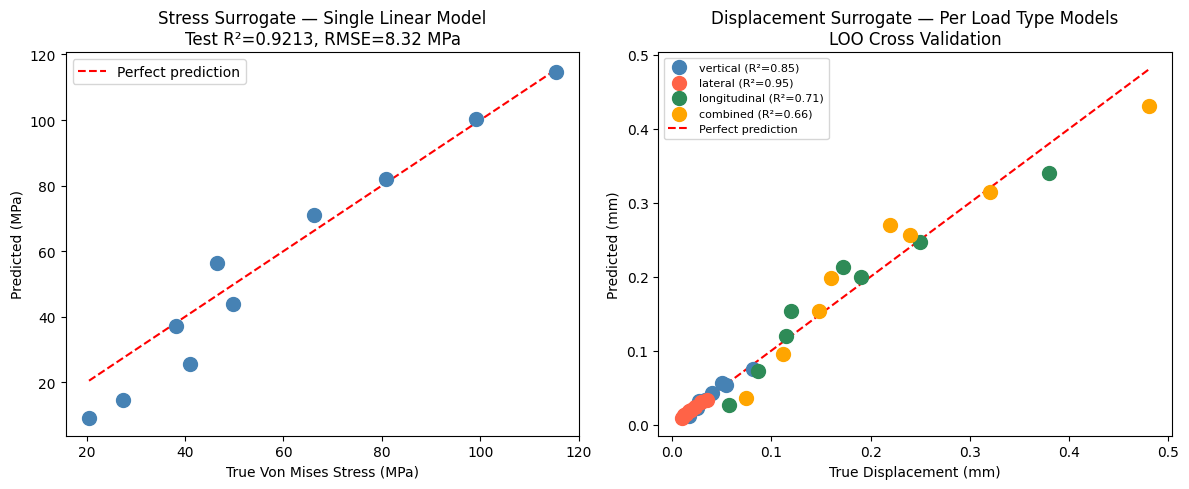

=== FINAL SURROGATE MODEL SUMMARY ===

Stress Model (single linear):
  Test R²:   0.9213
  Test RMSE: 8.32 MPa
  CV R²:     0.9649 ± 0.0195

Displacement Models (per load type):
  vertical        LOO R²: 0.8459  RMSE: 0.00755 mm
  lateral         LOO R²: 0.9546  RMSE: 0.00175 mm
  longitudinal    LOO R²: 0.7067  RMSE: 0.05281 mm
  combined        LOO R²: 0.6591  RMSE: 0.07142 mm


In [17]:
# Final surrogate model summary plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stress surrogate — already good
axes[0].scatter(y_stress_test, y_stress_pred,
                color='steelblue', s=100, zorder=5)
axes[0].plot([y_stress_test.min(), y_stress_test.max()],
             [y_stress_test.min(), y_stress_test.max()],
             'r--', label='Perfect prediction')
axes[0].set_xlabel("True Von Mises Stress (MPa)")
axes[0].set_ylabel("Predicted (MPa)")
axes[0].set_title(f"Stress Surrogate — Single Linear Model\nTest R²={r2_stress:.4f}, RMSE={np.sqrt(mse_stress):.2f} MPa")
axes[0].legend()

# Displacement surrogate — per load type
colors_load = {'vertical': 'steelblue', 'lateral': 'tomato',
               'longitudinal': 'seagreen', 'combined': 'orange'}

for load in load_types:
    mask = df['load_type'] == load
    X_load = df[mask][['geometry_encoded',
                        'force_vertical', 'force_lateral',
                        'force_longitudinal']].values
    y_load = df[mask]['displacement_mm'].values
    model, scaler_load = disp_models[load]
    y_pred_load = model.predict(scaler_load.transform(X_load))
    axes[1].scatter(y_load, y_pred_load,
                   color=colors_load[load],
                   label=f'{load} (R²={disp_results[load]["r2"]:.2f})',
                   s=100, zorder=5)

# Perfect prediction line
all_disp = df['displacement_mm'].values
axes[1].plot([all_disp.min(), all_disp.max()],
             [all_disp.min(), all_disp.max()],
             'r--', label='Perfect prediction')
axes[1].set_xlabel("True Displacement (mm)")
axes[1].set_ylabel("Predicted (mm)")
axes[1].set_title("Displacement Surrogate — Per Load Type Models\nLOO Cross Validation")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('surrogate_final_results.png', dpi=150)
plt.show()

print("=== FINAL SURROGATE MODEL SUMMARY ===")
print(f"\nStress Model (single linear):")
print(f"  Test R²:   {r2_stress:.4f}")
print(f"  Test RMSE: {np.sqrt(mse_stress):.2f} MPa")
print(f"  CV R²:     {cv_stress.mean():.4f} ± {cv_stress.std():.4f}")

print(f"\nDisplacement Models (per load type):")
for load in load_types:
    print(f"  {load:15s} LOO R²: {disp_results[load]['r2']:.4f}  "
          f"RMSE: {disp_results[load]['rmse']:.5f} mm")

**Key surrogate modeling lesson:**
A single global model forced to learn fundamentally different physical behaviors simultaneously will underperform.
Splitting by load type — a physically motivated grouping — dramatically improved displacement prediction.
This is called stratified modeling or local surrogate modeling.
The grouping variable (load type) should always be chosen based on physical understanding, not just data statistics.
Your FEM background told you that load direction fundamentally changes structural response. That domain knowledge directly improved the ML model.